# Causal Discovery with gCastle

[Documentation](https://gcastle.readthedocs.io/en/latest/)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import seaborn as sns

from castle.algorithms import PC
from castle.common import GraphDAG
from modules.create_data import create_stroke_data

2026-08-21 08:39:34,498 - /home/michael/miniconda3/envs/sam3/lib/python3.12/site-packages/castle/backend/__init__.py[line:36] - INFO: You can use `os.environ['CASTLE_BACKEND'] = backend` to set the backend(`pytorch` or `mindspore`).
2026-08-21 08:39:34,519 - /home/michael/miniconda3/envs/sam3/lib/python3.12/site-packages/castle/algorithms/__init__.py[line:36] - INFO: You are using ``pytorch`` as the backend.


In [2]:
all_data = create_stroke_data(n=10000, seed=42)
all_data.head()

,patient_id,year,age,ethnicity,male,warfarin,shoe_size,nihss,thrombolysis_time,thrombolysis,...,mortality_odds_no_treatment,mortality_log_odds_no_treatment,mortality_prob_treated,mortality_odds_treated,mortality_log_odds_treated,odds_ratio_treated,log_odds_ratio_treated,probability_difference,mortality_probability,died
0,1,2024,66,white,1,0,5,6,145.0,1,...,0.2346,-1.4500,0.0662,0.0709,-2.6467,3.3091,1.1967,0.1238,0.0662,0
1,2,2023,79,white,1,0,7,13,99999.0,0,...,0.4815,-0.7309,0.3250,0.4815,-0.7309,1.0000,0.0000,0.0000,0.3250,0
2,3,2021,88,white,1,0,8,7,301.0,1,...,0.4493,-0.8001,0.2450,0.3246,-1.1253,1.3843,0.3252,0.0650,0.2450,1
3,4,2020,74,white,0,0,9,11,99999.0,0,...,0.4925,-0.7082,0.3300,0.4925,-0.7082,1.0000,0.0000,0.0000,0.3300,0
4,5,2024,70,black,1,0,12,23,99999.0,0,...,0.9231,-0.0800,0.4800,0.9231,-0.0800,1.0000,0.0000,-0.0000,0.4800,1


In [4]:
data = all_data[[
'year',
 'age',
 'ethnicity',
 'male',
 'warfarin',
 'shoe_size',
 'nihss',
 'thrombolysis_time',
 # 'thrombolysis',
 'mortality_probability',
 'died']]

/tmp/ipykernel_13934/3860275599.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=['object', 'category', 'bool']).columns:


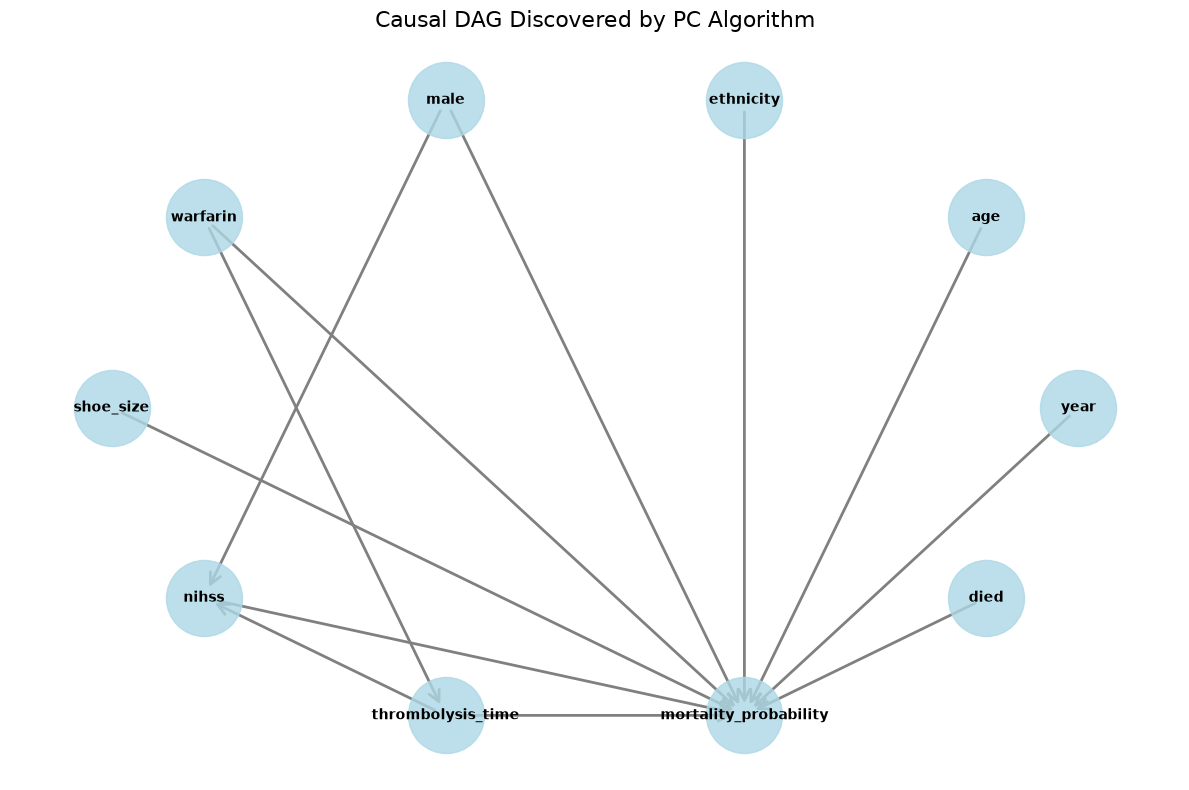

In [5]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from castle.algorithms import PC

# 1. Combine X and y into a single DataFrame
# Assuming X and y are already defined in your environment
df = data.copy(deep=True)  # Use a copy to avoid modifying the original data

# Store column names for plotting later
columns = df.columns.tolist()

# Convert any string, object, or boolean columns into numeric categories
for col in df.select_dtypes(include=['object', 'category', 'bool']).columns:
    df[col] = df[col].astype('category').cat.codes

# Force the entire DataFrame to float to satisfy NumPy's correlation functions
df = df.astype(float)

# 2. Initialize and fit the PC algorithm
# Note: By default, PC uses the Fisher-Z test (assumes continuous/linear data). 
# If your data is largely categorical/discrete, you may want to pass `ci_test='chi2'`.
model = PC(alpha=0.05) # Adjust alpha and ci_test as needed
model.learn(df)

# The algorithm outputs an adjacency matrix (causal matrix)
# 0: no edge, 1: directed edge (i -> j), -1: undirected edge (i - j)
adj_matrix = model.causal_matrix

# 3. Visualize the Causal DAG using NetworkX
def plot_dag(adj_matrix, labels):
    # Create a directed graph
    G = nx.DiGraph()
    
    # Add nodes
    for label in labels:
        G.add_node(label)
        
    # Add edges based on the adjacency matrix
    num_nodes = len(labels)
    for i in range(num_nodes):
        for j in range(num_nodes):
            if adj_matrix[i, j] == 1:
                G.add_edge(labels[i], labels[j])
                
    # Set up the plot
    plt.figure(figsize=(12, 8))
    
    # Use a spring layout for better spacing
    #pos = nx.spring_layout(G, k=1.5, seed=42)
    pos = nx.circular_layout(G)  # Use circular layout for better visualization of cycles
    
    # Draw the graph
    nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=3000, alpha=0.8)
    nx.draw_networkx_edges(G, pos, arrowstyle='->', arrowsize=20, edge_color='gray', width=2)
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')
    
    plt.title("Causal DAG Discovered by PC Algorithm", fontsize=16)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# Plot the graph
plot_dag(adj_matrix, columns)